# Cross-Code Comparative Analysis of Kazakhstan's Legal Codes

**Paper 2: Option A - Cross-Code Comparative Analysis**

This notebook analyzes and compares multiple legal codes from Kazakhstan's legal system:
- Criminal Code (Уголовный кодекс)
- Administrative Code (Об административных правонарушениях)
- Civil Code (Гражданский кодекс)
- Labor Code (Трудовой кодекс)
- Tax Code (Налоговый кодекс)

**Analysis dimensions:**
1. Corpus statistics (article counts, text lengths)
2. Vocabulary analysis (overlap, unique terms, Jaccard similarity)
3. TF-IDF term importance per code
4. Structural complexity metrics
5. Cross-code visualizations

## 1. Setup and Imports

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for Russian text
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Load spaCy Russian model
nlp = spacy.load("ru_core_news_sm")

print("Setup complete!")

Setup complete!


## 2. Data Loading

Load Russian versions of the 5 codes for comparison.

In [2]:
# Define codes to analyze (Russian versions from historical data)
# Using latest version from by_history folders
CODES = {
    "criminal": {
        "history_folder": "K1400000226_rus_ugolov",
        "name_ru": "Уголовный кодекс",
        "name_en": "Criminal Code",
        "short": "УК"
    },
    "administrative": {
        "history_folder": "K1400000235_rus_adm",
        "name_ru": "Кодекс об административных правонарушениях",
        "name_en": "Administrative Code",
        "short": "КоАП"
    },
    "civil": {
        "history_folder": "K940001000__rus_grazh",
        "name_ru": "Гражданский кодекс",
        "name_en": "Civil Code",
        "short": "ГК"
    },
    "labor": {
        "history_folder": "K1500000414_rus_trud",
        "name_ru": "Трудовой кодекс",
        "name_en": "Labor Code",
        "short": "ТК"
    },
    "tax": {
        "history_folder": "K2500000214_rus_nalog",
        "name_ru": "Налоговый кодекс",
        "name_en": "Tax Code",
        "short": "НК"
    }
}

DATA_PATH = Path("../data/raw/by_history")

In [3]:
def load_code(code_key):
    """Load the latest version of a legal code from historical data."""
    history_folder = DATA_PATH / CODES[code_key]["history_folder"]
    
    # Read versions index to find the latest version
    index_path = history_folder / "versions_index.json"
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    
    # Get the latest version (last entry in the versions array)
    latest_version = index["versions"][-1]
    version_file = history_folder / latest_version["filename"]
    
    # Load the version file
    with open(version_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Return articles array and version info
    return data["articles"], latest_version

# Load all codes
codes_data = {}
version_info = {}
for code_key in CODES:
    articles, ver_info = load_code(code_key)
    codes_data[code_key] = articles
    version_info[code_key] = ver_info
    print(f"{CODES[code_key]['short']}: {len(articles)} articles loaded (version {ver_info['version_number']}, {ver_info['version_date']})")

УК: 502 articles loaded (version 109, 16.09.2025)
КоАП: 1066 articles loaded (version 205, 17.12.2025)
ГК: 425 articles loaded (version 179, 20.11.2025)
ТК: 221 articles loaded (version 69, 16.09.2025)
НК: 848 articles loaded (version 1, 18.07.2025)


## 3. Corpus Statistics

In [4]:
def get_corpus_stats(data, code_key):
    """Calculate basic corpus statistics for a legal code."""
    articles = data
    
    # Count sections and chapters
    sections = set(a.get("section") for a in articles if a.get("section"))
    chapters = set(a.get("chapter") for a in articles if a.get("chapter"))
    
    # Text statistics
    article_texts = [a.get("article_text", "") for a in articles]
    text_lengths = [len(t) for t in article_texts]
    word_counts = [len(t.split()) for t in article_texts]
    
    # Paragraph counts
    para_counts = [len(a.get("paragraphs", [])) for a in articles]
    
    return {
        "code": CODES[code_key]["short"],
        "name_en": CODES[code_key]["name_en"],
        "articles": len(articles),
        "sections": len(sections),
        "chapters": len(chapters),
        "total_chars": sum(text_lengths),
        "total_words": sum(word_counts),
        "avg_article_words": np.mean(word_counts),
        "median_article_words": np.median(word_counts),
        "max_article_words": max(word_counts),
        "total_paragraphs": sum(para_counts),
        "avg_paragraphs_per_article": np.mean(para_counts)
    }

# Calculate stats for all codes
stats_list = []
for code_key in CODES:
    stats = get_corpus_stats(codes_data[code_key], code_key)
    stats_list.append(stats)

stats_df = pd.DataFrame(stats_list)
stats_df = stats_df.set_index("code")
stats_df

,name_en,articles,sections,chapters,total_chars,total_words,avg_article_words,median_article_words,max_article_words,total_paragraphs,avg_paragraphs_per_article
code,,,,,,,,,,,
УК,Criminal Code,502,6,17,671230,88791,176.874502,151.0,3848,2370,4.721116
КоАП,Administrative Code,1066,5,50,1443511,175126,164.283302,104.0,3066,4306,4.039400
ГК,Civil Code,425,3,22,376117,45757,107.663529,82.0,785,1385,3.258824
ТК,Labor Code,221,4,18,359546,42929,194.248869,124.0,2755,1588,7.185520
НК,Tax Code,848,22,95,2293410,278677,328.628538,219.5,5616,7596,8.957547


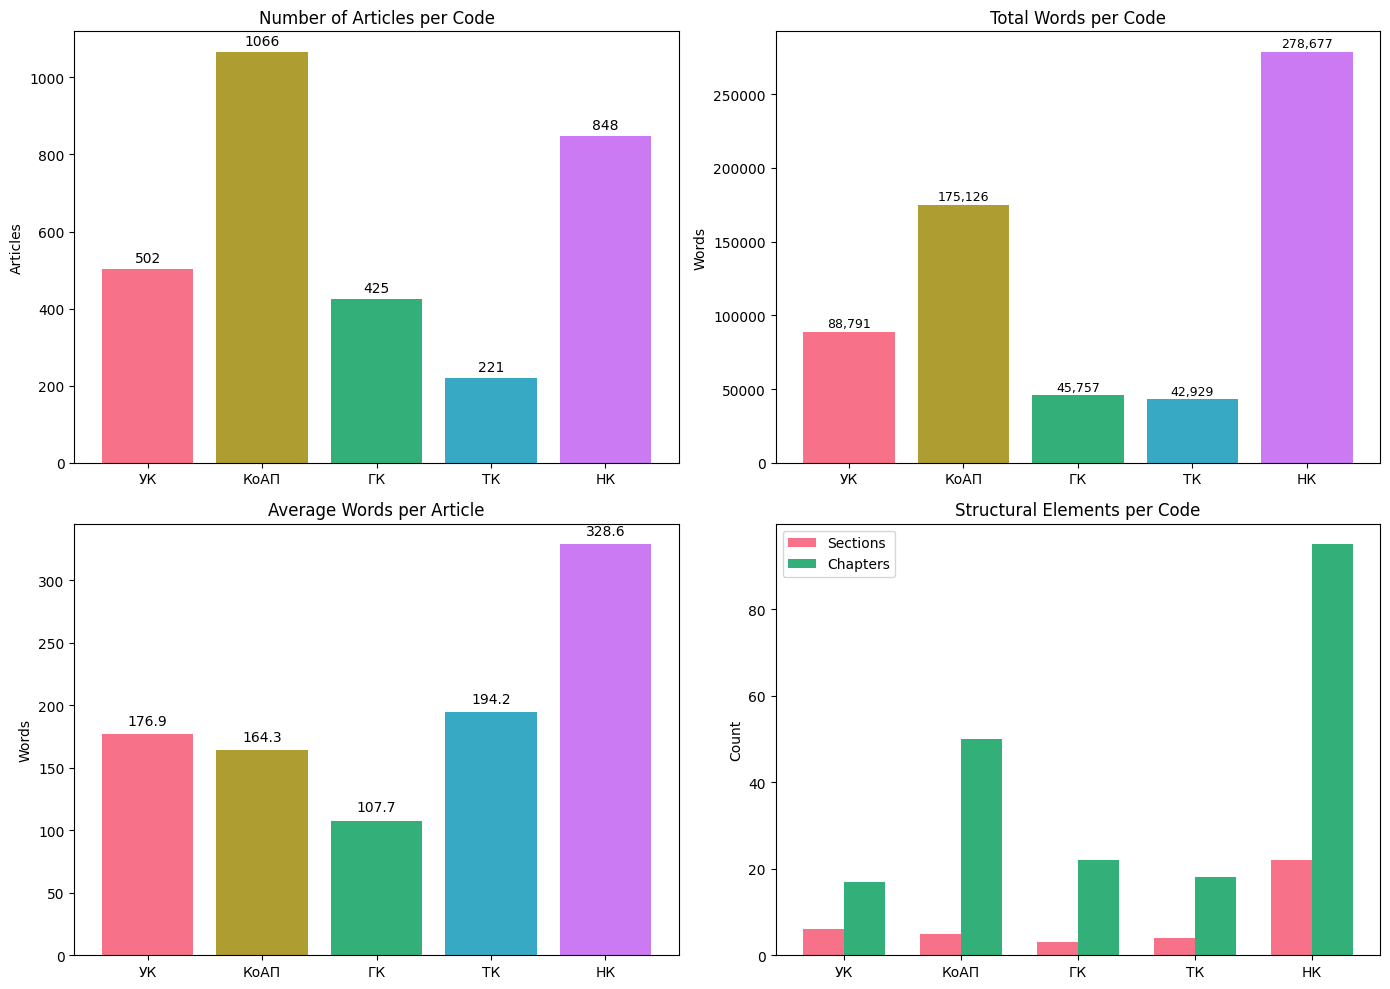

In [5]:
# Visualize corpus statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

codes_short = [CODES[k]["short"] for k in CODES]
colors = sns.color_palette("husl", len(CODES))

# Article count
ax1 = axes[0, 0]
bars = ax1.bar(codes_short, stats_df["articles"], color=colors)
ax1.set_title("Number of Articles per Code", fontsize=12)
ax1.set_ylabel("Articles")
for bar, val in zip(bars, stats_df["articles"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(int(val)), ha='center', va='bottom', fontsize=10)

# Total words
ax2 = axes[0, 1]
bars = ax2.bar(codes_short, stats_df["total_words"], color=colors)
ax2.set_title("Total Words per Code", fontsize=12)
ax2.set_ylabel("Words")
for bar, val in zip(bars, stats_df["total_words"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f"{int(val):,}", ha='center', va='bottom', fontsize=9)

# Average article length
ax3 = axes[1, 0]
bars = ax3.bar(codes_short, stats_df["avg_article_words"], color=colors)
ax3.set_title("Average Words per Article", fontsize=12)
ax3.set_ylabel("Words")
for bar, val in zip(bars, stats_df["avg_article_words"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f"{val:.1f}", ha='center', va='bottom', fontsize=10)

# Sections and chapters
ax4 = axes[1, 1]
x = np.arange(len(codes_short))
width = 0.35
ax4.bar(x - width/2, stats_df["sections"], width, label="Sections", color=colors[0])
ax4.bar(x + width/2, stats_df["chapters"], width, label="Chapters", color=colors[2])
ax4.set_xticks(x)
ax4.set_xticklabels(codes_short)
ax4.set_title("Structural Elements per Code", fontsize=12)
ax4.set_ylabel("Count")
ax4.legend()

plt.tight_layout()
plt.savefig("../output/01/corpus_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Preprocessing Pipeline

In [6]:
def preprocess_text(text):
    """Preprocess Russian legal text: lowercase, lemmatize, remove stopwords."""
    doc = nlp(text.lower())
    tokens = [
        t.lemma_ for t in doc 
        if not t.is_punct 
        and not t.is_space 
        and not t.is_stop
        and len(t.text) > 2
        and not t.text.isdigit()
    ]
    return tokens

def get_vocabulary(data):
    """Get preprocessed vocabulary (unique lemmas) for a code.
    Processes article by article to avoid spaCy text length limits.
    """
    all_tokens = []
    for article in data:
        text = article.get("article_text", "")
        if text:
            tokens = preprocess_text(text)
            all_tokens.extend(tokens)
    return set(all_tokens), all_tokens

# Test preprocessing
test_text = "Административное правонарушение влечет ответственность согласно закону."
print("Original:", test_text)
print("Preprocessed:", preprocess_text(test_text))

Original: Административное правонарушение влечет ответственность согласно закону.
Preprocessed: ['административный', 'правонарушение', 'влечь', 'ответственность', 'согласно', 'закон']


In [7]:
# Process all codes (this may take a few minutes)
print("Processing codes (article by article to handle large texts)...")
vocabularies = {}
all_tokens = {}

for code_key in CODES:
    n_articles = len(codes_data[code_key])
    print(f"  Processing {CODES[code_key]['short']} ({n_articles} articles)...", end=" ", flush=True)
    vocab, tokens = get_vocabulary(codes_data[code_key])
    vocabularies[code_key] = vocab
    all_tokens[code_key] = tokens
    print(f"{len(vocab):,} unique lemmas, {len(tokens):,} total tokens")

print("\nProcessing complete!")

Processing codes (article by article to handle large texts)...
  Processing УК (502 articles)... 2,790 unique lemmas, 58,628 total tokens
  Processing КоАП (1066 articles)... 5,112 unique lemmas, 123,401 total tokens
  Processing ГК (425 articles)... 2,641 unique lemmas, 30,742 total tokens
  Processing ТК (221 articles)... 2,386 unique lemmas, 30,480 total tokens
  Processing НК (848 articles)... 5,481 unique lemmas, 197,256 total tokens

Processing complete!


## 5. Vocabulary Analysis

In [8]:
# Vocabulary size comparison
vocab_sizes = {CODES[k]["short"]: len(v) for k, v in vocabularies.items()}
token_counts = {CODES[k]["short"]: len(t) for k, t in all_tokens.items()}

vocab_df = pd.DataFrame({
    "Code": list(vocab_sizes.keys()),
    "Unique Lemmas": list(vocab_sizes.values()),
    "Total Tokens": list(token_counts.values())
})
vocab_df["Type-Token Ratio"] = vocab_df["Unique Lemmas"] / vocab_df["Total Tokens"]
vocab_df = vocab_df.set_index("Code")
vocab_df

,Unique Lemmas,Total Tokens,Type-Token Ratio
Code,,,
УК,2790,58628,0.047588
КоАП,5112,123401,0.041426
ГК,2641,30742,0.085909
ТК,2386,30480,0.078281
НК,5481,197256,0.027786


In [9]:
def jaccard_similarity(set1, set2):
    """Calculate Jaccard similarity between two sets."""
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

# Calculate pairwise Jaccard similarity matrix
code_keys = list(CODES.keys())
n = len(code_keys)
jaccard_matrix = np.zeros((n, n))

for i, k1 in enumerate(code_keys):
    for j, k2 in enumerate(code_keys):
        jaccard_matrix[i, j] = jaccard_similarity(vocabularies[k1], vocabularies[k2])

# Create DataFrame
code_labels = [CODES[k]["short"] for k in code_keys]
jaccard_df = pd.DataFrame(jaccard_matrix, index=code_labels, columns=code_labels)
print("Jaccard Similarity Matrix (Vocabulary Overlap):")
jaccard_df.round(3)

Jaccard Similarity Matrix (Vocabulary Overlap):


,УК,КоАП,ГК,ТК,НК
УК,1.000,0.337,0.301,0.313,0.247
КоАП,0.337,1.000,0.276,0.290,0.356
ГК,0.301,0.276,1.000,0.316,0.276
ТК,0.313,0.290,0.316,1.000,0.268
НК,0.247,0.356,0.276,0.268,1.000


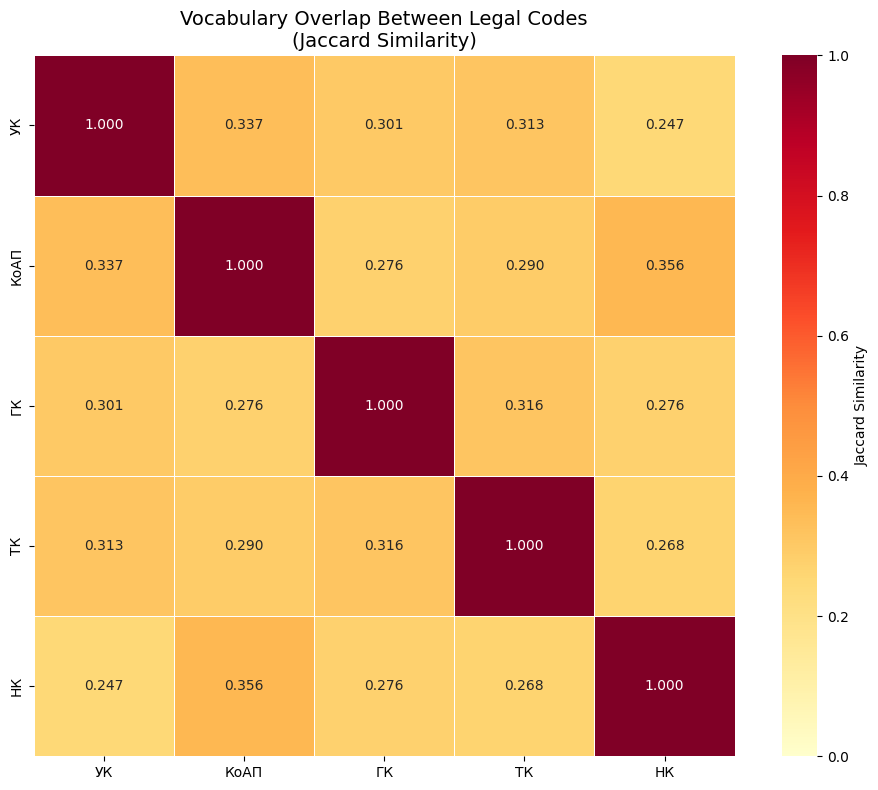

In [10]:
# Visualize Jaccard similarity heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(jaccard_matrix, dtype=bool), k=1)

sns.heatmap(
    jaccard_df, 
    annot=True, 
    fmt=".3f", 
    cmap="YlOrRd",
    vmin=0, 
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Jaccard Similarity"}
)
plt.title("Vocabulary Overlap Between Legal Codes\n(Jaccard Similarity)", fontsize=14)
plt.tight_layout()
plt.savefig("../output/01/jaccard_similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Find shared vocabulary (terms in ALL codes)
shared_vocab = set.intersection(*vocabularies.values())
print(f"Terms shared across ALL codes: {len(shared_vocab):,}")

# Find unique terms per code (not in any other code)
unique_terms = {}
for code_key in CODES:
    other_vocabs = [v for k, v in vocabularies.items() if k != code_key]
    other_union = set.union(*other_vocabs)
    unique = vocabularies[code_key] - other_union
    unique_terms[code_key] = unique
    print(f"{CODES[code_key]['short']}: {len(unique):,} unique terms")

Terms shared across ALL codes: 815
УК: 547 unique terms
КоАП: 1,590 unique terms
ГК: 569 unique terms
ТК: 386 unique terms
НК: 2,164 unique terms


In [12]:
# Display sample unique terms per code
print("\nSample unique terms per code (domain-specific vocabulary):")
print("="*60)

for code_key in CODES:
    # Get most frequent unique terms
    unique = unique_terms[code_key]
    token_freq = Counter(all_tokens[code_key])
    unique_freq = {t: token_freq[t] for t in unique if t in token_freq}
    top_unique = sorted(unique_freq.items(), key=lambda x: x[1], reverse=True)[:15]
    
    print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}):")
    for term, freq in top_unique:
        print(f"  {term}: {freq}")


Sample unique terms per code (domain-specific vocabulary):

Criminal Code (УК):
  наказываться: 1047
  сговору: 137
  неоднократно: 120
  небольшой: 45
  отбытие: 31
  осужденного: 28
  транснациональный: 23
  побуждение: 22
  беспорядок: 19
  неотбытый: 19
  нападение: 18
  вымогательство: 18
  рецидив: 17
  мягкий: 16
  потерпевшей: 15

Administrative Code (КоАП):
  досмотр: 64
  семидесяти: 52
  девятый: 50
  семьсот: 49
  четырехсот: 43
  привод: 39
  аукционный: 26
  сокращенного: 23
  подкарантинный: 22
  привлекаемого: 20
  теле-: 19
  правонарушитель: 18
  антиконкурентный: 17
  аттестат: 17
  десятой: 16

Civil Code (ГК):
  коммандитный: 33
  оферта: 23
  ничтожный: 21
  вещный: 20
  частность: 16
  товарищ: 16
  натура: 13
  т.п.: 12
  очередь: 11
  будущее: 11
  дееспособность: 10
  просрочить: 9
  обеспечительный: 9
  выдела: 8
  ничтожность: 8

Labor Code (ТК):
  согласительный: 50
  оплачивать: 32
  примирительный: 26
  распорядок: 18
  возглавлять: 13
  пятидневный: 13


## 6. TF-IDF Analysis

In [13]:
# Prepare documents for TF-IDF (one document per code)
documents = []
for code_key in CODES:
    doc_text = " ".join(all_tokens[code_key])
    documents.append(doc_text)

# Calculate TF-IDF
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 1))
tfidf_matrix = tfidf.fit_transform(documents)

# Get feature names
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Features (terms): {len(feature_names)}")

TF-IDF matrix shape: (5, 1000)
Features (terms): 1000


In [14]:
# Get top TF-IDF terms per code
def get_top_tfidf_terms(tfidf_matrix, feature_names, doc_idx, n=20):
    """Get top n terms by TF-IDF score for a document."""
    scores = tfidf_matrix[doc_idx].toarray().flatten()
    top_indices = scores.argsort()[-n:][::-1]
    return [(feature_names[i], scores[i]) for i in top_indices]

# Display top terms for each code
print("Top 15 Most Important Terms per Code (TF-IDF):")
print("="*60)

for i, code_key in enumerate(CODES):
    top_terms = get_top_tfidf_terms(tfidf_matrix, feature_names, i, n=15)
    print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}):")
    for term, score in top_terms:
        print(f"  {term}: {score:.4f}")

Top 15 Most Important Terms per Code (TF-IDF):

Criminal Code (УК):
  срок: 0.4045
  наказываться: 0.3731
  лишение: 0.2668
  свобода: 0.2651
  год: 0.2362
  лицо: 0.2109
  размер: 0.1950
  работа: 0.1680
  деяние: 0.1628
  определённый: 0.1506
  совершить: 0.1228
  исправительный: 0.1220
  штраф: 0.1120
  преступление: 0.1115
  статья: 0.1051

Administrative Code (КоАП):
  размер: 0.4098
  лицо: 0.3160
  субъект: 0.2590
  предпринимательство: 0.2417
  штраф: 0.2337
  административный: 0.2199
  влечь: 0.1969
  показатель: 0.1820
  расчётный: 0.1817
  месячный: 0.1813
  часть: 0.1666
  статья: 0.1330
  казахстан: 0.1316
  республика: 0.1313
  настоящий: 0.1290

Civil Code (ГК):
  лицо: 0.3501
  право: 0.2751
  имущество: 0.2688
  договор: 0.2173
  обязательство: 0.1972
  товарищество: 0.1879
  акт: 0.1784
  предусмотреть: 0.1755
  казахстан: 0.1577
  республика: 0.1577
  законодательный: 0.1572
  случай: 0.1544
  юридический: 0.1481
  кредитор: 0.1421
  настоящий: 0.1346

Labor Code (ТК

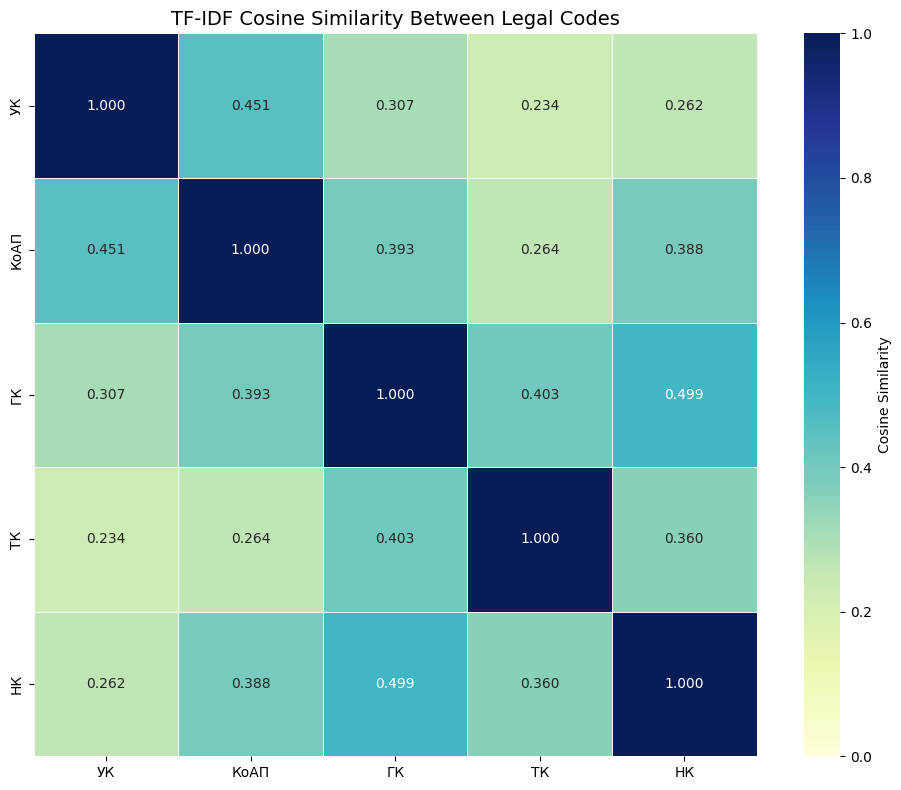


Cosine Similarity Matrix:


,УК,КоАП,ГК,ТК,НК
УК,1.000,0.451,0.307,0.234,0.262
КоАП,0.451,1.000,0.393,0.264,0.388
ГК,0.307,0.393,1.000,0.403,0.499
ТК,0.234,0.264,0.403,1.000,0.360
НК,0.262,0.388,0.499,0.360,1.000


In [15]:
# Visualize TF-IDF cosine similarity between codes
cosine_sim = cosine_similarity(tfidf_matrix)
cosine_df = pd.DataFrame(cosine_sim, index=code_labels, columns=code_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cosine_df, 
    annot=True, 
    fmt=".3f", 
    cmap="YlGnBu",
    vmin=0, 
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Cosine Similarity"}
)
plt.title("TF-IDF Cosine Similarity Between Legal Codes", fontsize=14)
plt.tight_layout()
plt.savefig("../output/01/tfidf_cosine_similarity.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nCosine Similarity Matrix:")
cosine_df.round(3)

## 7. Word Frequency Analysis

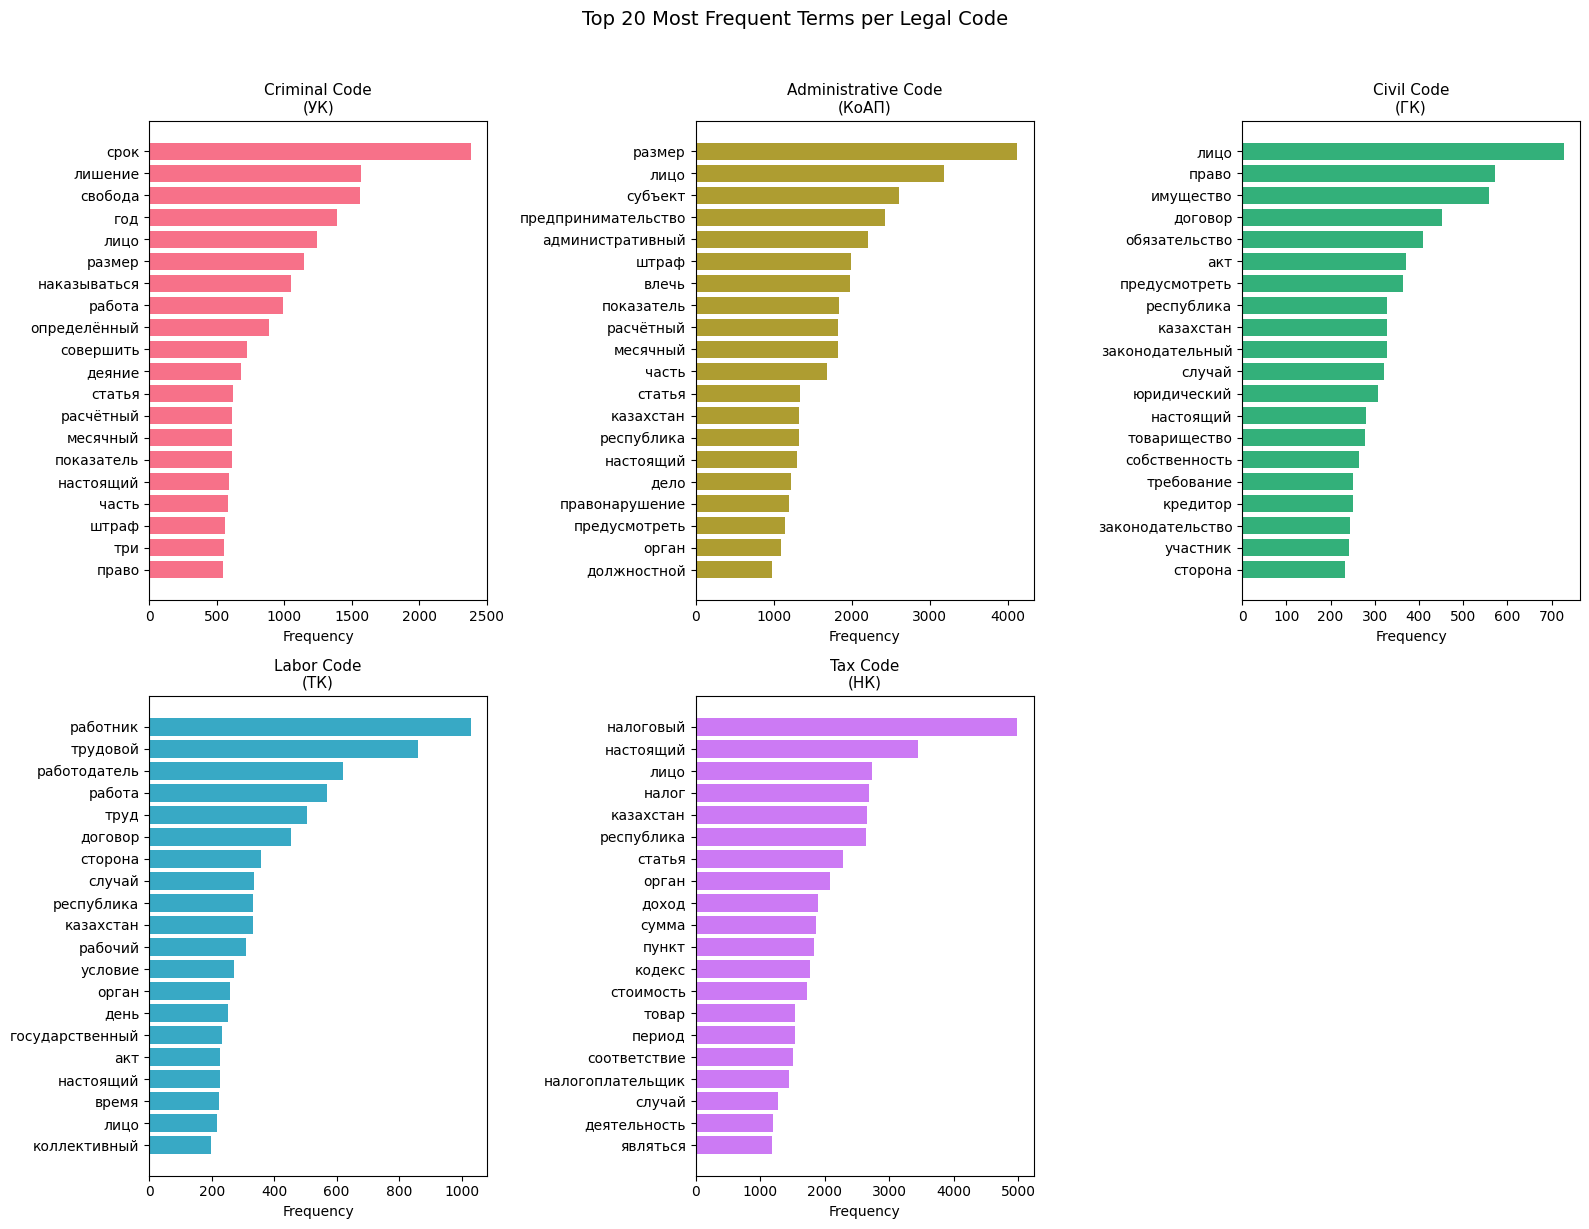

In [16]:
# Top 20 most frequent terms per code
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, code_key in enumerate(CODES):
    ax = axes[i]
    freq = Counter(all_tokens[code_key]).most_common(20)
    terms, counts = zip(*freq)
    
    bars = ax.barh(range(len(terms)), counts, color=sns.color_palette("husl", len(CODES))[i])
    ax.set_yticks(range(len(terms)))
    ax.set_yticklabels(terms)
    ax.invert_yaxis()
    ax.set_title(f"{CODES[code_key]['name_en']}\n({CODES[code_key]['short']})", fontsize=11)
    ax.set_xlabel("Frequency")

# Hide empty subplot
axes[-1].axis('off')

plt.suptitle("Top 20 Most Frequent Terms per Legal Code", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../output/01/word_frequency_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Structural Complexity Metrics

In [17]:
def calculate_complexity_metrics(data, code_key):
    """Calculate text complexity metrics for a legal code."""
    metrics = {"code": CODES[code_key]["short"]}
    
    # Sentence-level analysis
    all_sentences = []
    all_words_per_sent = []
    
    for article in data:
        text = article.get("article_text", "")
        doc = nlp(text)
        for sent in doc.sents:
            sent_words = [t for t in sent if not t.is_punct and not t.is_space]
            if len(sent_words) > 0:
                all_sentences.append(sent.text)
                all_words_per_sent.append(len(sent_words))
    
    metrics["total_sentences"] = len(all_sentences)
    metrics["avg_sentence_length"] = np.mean(all_words_per_sent) if all_words_per_sent else 0
    metrics["max_sentence_length"] = max(all_words_per_sent) if all_words_per_sent else 0
    metrics["median_sentence_length"] = np.median(all_words_per_sent) if all_words_per_sent else 0
    
    # Vocabulary richness (Type-Token Ratio)
    tokens = all_tokens[code_key]
    metrics["vocabulary_size"] = len(vocabularies[code_key])
    metrics["ttr"] = len(vocabularies[code_key]) / len(tokens) if tokens else 0
    
    # Average word length
    word_lengths = [len(t) for t in tokens]
    metrics["avg_word_length"] = np.mean(word_lengths) if word_lengths else 0
    
    return metrics

# Calculate complexity for all codes (this takes time due to sentence parsing)
print("Calculating complexity metrics...")
complexity_list = []

for code_key in CODES:
    print(f"  Processing {CODES[code_key]['short']}...")
    metrics = calculate_complexity_metrics(codes_data[code_key], code_key)
    complexity_list.append(metrics)

complexity_df = pd.DataFrame(complexity_list).set_index("code")
complexity_df.round(3)

Calculating complexity metrics...
  Processing УК...
  Processing КоАП...
  Processing ГК...
  Processing ТК...
  Processing НК...


,total_sentences,avg_sentence_length,max_sentence_length,median_sentence_length,vocabulary_size,ttr,avg_word_length
code,,,,,,,
УК,3994,21.944,818,10.0,2790,0.048,8.074
КоАП,7717,22.019,723,15.0,5112,0.041,8.693
ГК,3091,14.787,148,13.0,2641,0.086,8.794
ТК,2581,16.616,247,15.0,2386,0.078,8.786
НК,12717,21.764,704,17.0,5481,0.028,8.556


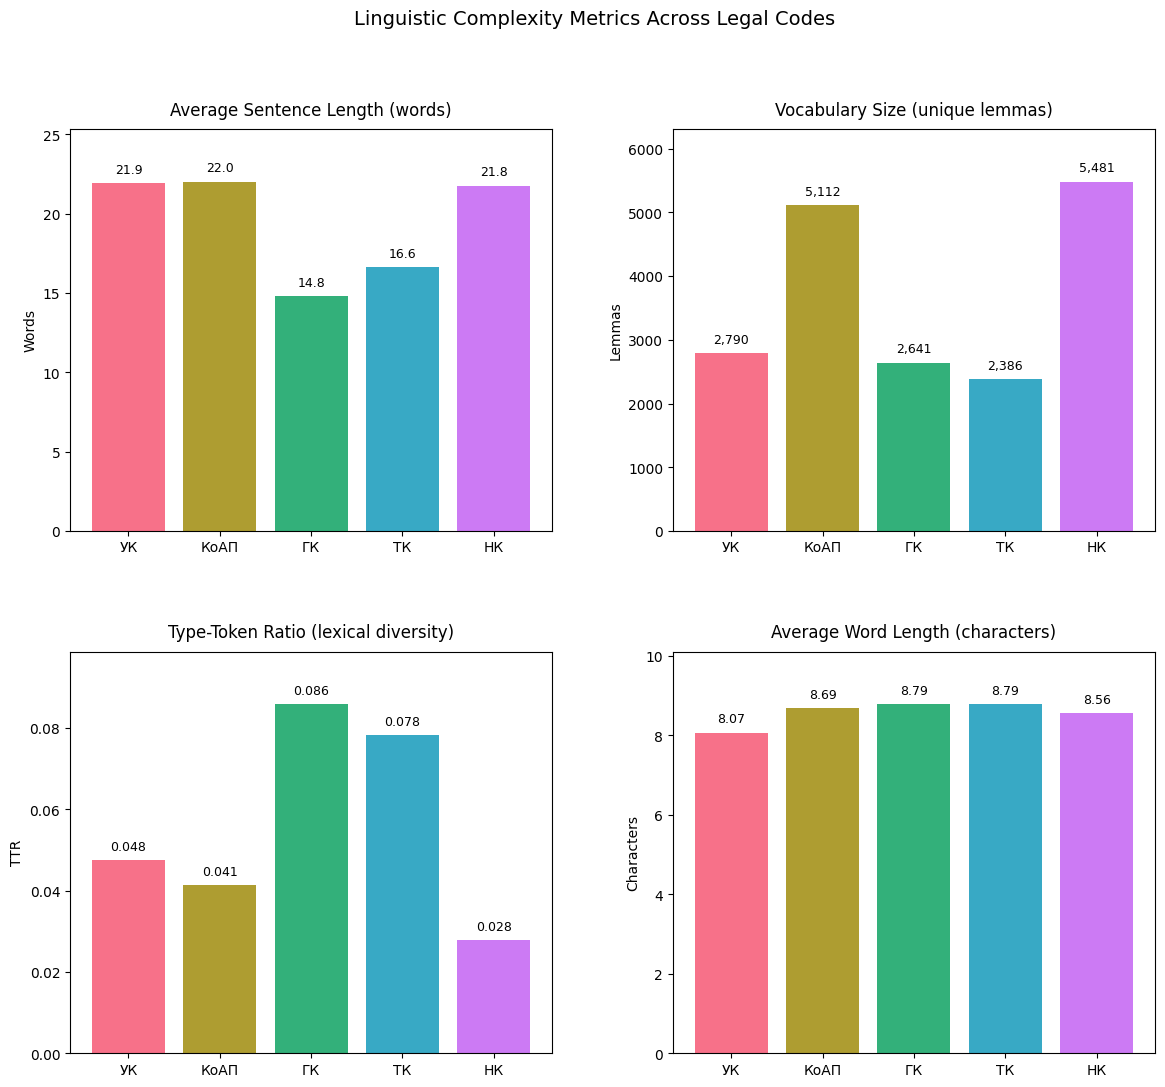

In [18]:
# Visualize complexity metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

codes_short = [CODES[k]["short"] for k in CODES]
colors = sns.color_palette("husl", len(CODES))

# Average sentence length
ax1 = axes[0, 0]
vals = complexity_df["avg_sentence_length"].values
bars = ax1.bar(codes_short, vals, color=colors)
ax1.set_title("Average Sentence Length (words)", fontsize=12, pad=10)
ax1.set_ylabel("Words")
ax1.set_ylim(0, max(vals) * 1.15)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02, 
             f"{val:.1f}", ha='center', va='bottom', fontsize=9)

# Vocabulary size
ax2 = axes[0, 1]
vals = complexity_df["vocabulary_size"].values
bars = ax2.bar(codes_short, vals, color=colors)
ax2.set_title("Vocabulary Size (unique lemmas)", fontsize=12, pad=10)
ax2.set_ylabel("Lemmas")
ax2.set_ylim(0, max(vals) * 1.15)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02, 
             f"{int(val):,}", ha='center', va='bottom', fontsize=9)

# Type-Token Ratio
ax3 = axes[1, 0]
vals = complexity_df["ttr"].values
bars = ax3.bar(codes_short, vals, color=colors)
ax3.set_title("Type-Token Ratio (lexical diversity)", fontsize=12, pad=10)
ax3.set_ylabel("TTR")
ax3.set_ylim(0, max(vals) * 1.15)
for bar, val in zip(bars, vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02, 
             f"{val:.3f}", ha='center', va='bottom', fontsize=9)

# Average word length
ax4 = axes[1, 1]
vals = complexity_df["avg_word_length"].values
bars = ax4.bar(codes_short, vals, color=colors)
ax4.set_title("Average Word Length (characters)", fontsize=12, pad=10)
ax4.set_ylabel("Characters")
ax4.set_ylim(0, max(vals) * 1.15)
for bar, val in zip(bars, vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02, 
             f"{val:.2f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Linguistic Complexity Metrics Across Legal Codes", fontsize=14, y=0.98)
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.savefig("../output/01/complexity_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Statistics Export

In [19]:
# Merge all statistics into one comprehensive table
summary_df = stats_df.copy()
summary_df = summary_df.merge(vocab_df, left_index=True, right_index=True)
summary_df = summary_df.merge(complexity_df, left_index=True, right_index=True)

# Select key columns
key_columns = [
    "name_en", "articles", "sections", "chapters",
    "total_words", "avg_article_words", 
    "Unique Lemmas", "Type-Token Ratio",
    "avg_sentence_length", "avg_word_length"
]

summary_export = summary_df[key_columns].copy()
summary_export.columns = [
    "Code Name", "Articles", "Sections", "Chapters",
    "Total Words", "Avg Words/Article",
    "Vocabulary Size", "Type-Token Ratio",
    "Avg Sentence Length", "Avg Word Length"
]

print("Summary Statistics:")
summary_export.round(3)

Summary Statistics:


,Code Name,Articles,Sections,Chapters,Total Words,Avg Words/Article,Vocabulary Size,Type-Token Ratio,Avg Sentence Length,Avg Word Length
УК,Criminal Code,502,6,17,88791,176.875,2790,0.048,21.944,8.074
КоАП,Administrative Code,1066,5,50,175126,164.283,5112,0.041,22.019,8.693
ГК,Civil Code,425,3,22,45757,107.664,2641,0.086,14.787,8.794
ТК,Labor Code,221,4,18,42929,194.249,2386,0.078,16.616,8.786
НК,Tax Code,848,22,95,278677,328.629,5481,0.028,21.764,8.556


In [20]:
# Export to CSV
summary_export.to_csv("../output/01/cross_code_summary_statistics.csv")
jaccard_df.to_csv("../output/01/jaccard_similarity_matrix.csv")
cosine_df.to_csv("../output/01/tfidf_cosine_similarity_matrix.csv")

print("Exported to output/01/:")
print("  - cross_code_summary_statistics.csv")
print("  - jaccard_similarity_matrix.csv")
print("  - tfidf_cosine_similarity_matrix.csv")

Exported to output/01/:
  - cross_code_summary_statistics.csv
  - jaccard_similarity_matrix.csv
  - tfidf_cosine_similarity_matrix.csv


## 10. Key Findings Summary

In [22]:
print("="*70)
print("KEY FINDINGS - Cross-Code Comparative Analysis")
print("="*70)

# Get actual values from computed data
print("\n" + "="*70)
print("1. CORPUS SIZE & STRUCTURE")
print("="*70)
print(f"""
   CODE VERSIONS (from historical data):
   • УК: version {version_info['criminal']['version_number']} ({version_info['criminal']['version_date']})
   • КоАП: version {version_info['administrative']['version_number']} ({version_info['administrative']['version_date']})
   • ГК: version {version_info['civil']['version_number']} ({version_info['civil']['version_date']})
   • ТК: version {version_info['labor']['version_number']} ({version_info['labor']['version_date']})
   • НК: version {version_info['tax']['version_number']} ({version_info['tax']['version_date']})
   
   ARTICLE COUNTS:
   • Administrative Code (КоАП) has the MOST articles: {stats_df.loc['КоАП', 'articles']:,}
   • Tax Code (НК) is the LARGEST by volume: {stats_df.loc['НК', 'total_words']:,} words
   • Tax Code has most complex structure: {stats_df.loc['НК', 'sections']} sections, {stats_df.loc['НК', 'chapters']} chapters
   • Labor Code (ТК) is the smallest: only {stats_df.loc['ТК', 'articles']} articles
   • Tax Code articles are longest on average: {stats_df.loc['НК', 'avg_article_words']:.0f} words/article
   • Civil Code articles are shortest: only {stats_df.loc['ГК', 'avg_article_words']:.0f} words/article
""")

print("="*70)
print("2. VOCABULARY & LEXICAL DIVERSITY")
print("="*70)
print(f"""
   VOCABULARY SIZE (unique lemmas after preprocessing):
   • Tax Code (НК) has largest vocabulary: {vocab_df.loc['НК', 'Unique Lemmas']:,} unique lemmas
   • Administrative Code (КоАП) close second: {vocab_df.loc['КоАП', 'Unique Lemmas']:,} unique lemmas
   • Labor Code (ТК) has smallest vocabulary: {vocab_df.loc['ТК', 'Unique Lemmas']:,} unique lemmas
   
   TYPE-TOKEN RATIO (lexical diversity - higher = more varied language):
   • Civil Code (ГК): {vocab_df.loc['ГК', 'Type-Token Ratio']:.3f} - MOST diverse vocabulary
   • Labor Code (ТК): {vocab_df.loc['ТК', 'Type-Token Ratio']:.3f} - Second most diverse
   • Tax Code (НК): {vocab_df.loc['НК', 'Type-Token Ratio']:.3f} - MOST repetitive language
   
   SHARED VOCABULARY:
   • {len(shared_vocab)} terms appear in ALL five codes (common legal terminology)
""")

print("="*70)
print("3. CODE SIMILARITY ANALYSIS")
print("="*70)
print(f"""
   MOST SIMILAR PAIRS (Jaccard vocabulary overlap):
   • КоАП & НК: {jaccard_df.loc['КоАП', 'НК']:.3f} - Both deal with violations/penalties
   • УК & КоАП: {jaccard_df.loc['УК', 'КоАП']:.3f} - Both cover offenses (criminal vs admin)
   • ГК & ТК: {jaccard_df.loc['ГК', 'ТК']:.3f} - Both regulate civil relationships
   
   LEAST SIMILAR PAIRS:
   • НК & УК: {jaccard_df.loc['НК', 'УК']:.3f} - Tax vs Criminal (distinct domains)
   • НК & ТК: {jaccard_df.loc['НК', 'ТК']:.3f} - Tax vs Labor (specialized vocabularies)
""")

print("="*70)
print("4. LINGUISTIC COMPLEXITY")
print("="*70)
print(f"""
   SENTENCE LENGTH (average words per sentence):
   • Criminal Code (УК): {complexity_df.loc['УК', 'avg_sentence_length']:.1f} words
   • Administrative Code (КоАП): {complexity_df.loc['КоАП', 'avg_sentence_length']:.1f} words
   • Tax Code (НК): {complexity_df.loc['НК', 'avg_sentence_length']:.1f} words
   • Labor Code (ТК): {complexity_df.loc['ТК', 'avg_sentence_length']:.1f} words
   • Civil Code (ГК): {complexity_df.loc['ГК', 'avg_sentence_length']:.1f} words - SIMPLEST sentences
   
   WORD LENGTH (average characters):
   • Civil Code (ГК): {complexity_df.loc['ГК', 'avg_word_length']:.2f} chars - Longest technical terms
   • Labor Code (ТК): {complexity_df.loc['ТК', 'avg_word_length']:.2f} chars
   • Administrative Code (КоАП): {complexity_df.loc['КоАП', 'avg_word_length']:.2f} chars
   • Tax Code (НК): {complexity_df.loc['НК', 'avg_word_length']:.2f} chars
   • Criminal Code (УК): {complexity_df.loc['УК', 'avg_word_length']:.2f} chars - Shorter words
   
   MAXIMUM SENTENCE LENGTH (words):
   • Criminal Code (УК): {int(complexity_df.loc['УК', 'max_sentence_length'])} words
   • Administrative Code (КоАП): {int(complexity_df.loc['КоАП', 'max_sentence_length'])} words
   • Tax Code (НК): {int(complexity_df.loc['НК', 'max_sentence_length'])} words
""")

print("="*70)
print("5. DOMAIN-SPECIFIC TERMINOLOGY")
print("="*70)
print(f"""
   UNIQUE TERMS PER CODE (not found in other codes):
   • Tax Code (НК): {len(unique_terms['tax']):,} unique terms (еаэс, лизинг, акциз, мрп)
   • Administrative Code (КоАП): {len(unique_terms['administrative']):,} terms (досмотр, привод)
   • Civil Code (ГК): {len(unique_terms['civil']):,} terms (оферта, ничтожный, коммандитный)
   • Criminal Code (УК): {len(unique_terms['criminal']):,} terms (наказываться, сговору, рецидив)
   • Labor Code (ТК): {len(unique_terms['labor']):,} terms (согласительный, примирительный)
   
   TOP TF-IDF DISCRIMINATIVE TERMS:
   • УК: срок, наказываться, лишение, свобода (punishment terms)
   • КоАП: размер, субъект, предпринимательство (fine calculations)
   • ГК: лицо, право, имущество, договор (property/contracts)
   • ТК: работник, работодатель, трудовой (employment relations)
   • НК: налоговый, налогоплательщик, доход (taxation)
""")

print("="*70)
print("6. KEY INSIGHTS FOR LEGAL NLP")
print("="*70)
print(f"""
   • Tax Code requires specialized preprocessing due to high repetition (TTR: {vocab_df.loc['НК', 'Type-Token Ratio']:.3f})
   • Civil Code's simpler sentences ({complexity_df.loc['ГК', 'avg_sentence_length']:.1f} words avg) may be easier for NLP parsing
   • Criminal & Administrative codes share terminology (Jaccard: {jaccard_df.loc['УК', 'КоАП']:.3f})
   • Each code has distinct domain vocabulary requiring separate training
   • {len(shared_vocab)} shared terms form a common "legal language" foundation
   • Sentence complexity varies: {complexity_df['avg_sentence_length'].min():.1f}-{complexity_df['avg_sentence_length'].max():.1f} words avg
   • Total corpus: {stats_df['articles'].sum():,} articles, {stats_df['total_words'].sum():,} words
""")

print("="*70)

KEY FINDINGS - Cross-Code Comparative Analysis

1. CORPUS SIZE & STRUCTURE

   CODE VERSIONS (from historical data):
   • УК: version 109 (16.09.2025)
   • КоАП: version 205 (17.12.2025)
   • ГК: version 179 (20.11.2025)
   • ТК: version 69 (16.09.2025)
   • НК: version 1 (18.07.2025)

   ARTICLE COUNTS:
   • Administrative Code (КоАП) has the MOST articles: 1,066
   • Tax Code (НК) is the LARGEST by volume: 278,677 words
   • Tax Code has most complex structure: 22 sections, 95 chapters
   • Labor Code (ТК) is the smallest: only 221 articles
   • Tax Code articles are longest on average: 329 words/article
   • Civil Code articles are shortest: only 108 words/article

2. VOCABULARY & LEXICAL DIVERSITY

   VOCABULARY SIZE (unique lemmas after preprocessing):
   • Tax Code (НК) has largest vocabulary: 5,481 unique lemmas
   • Administrative Code (КоАП) close second: 5,112 unique lemmas
   • Labor Code (ТК) has smallest vocabulary: 2,386 unique lemmas

   TYPE-TOKEN RATIO (lexical diversi